In [2]:
# EXPLORATORY DATA ANALYSIS - INDUSTRY PERFORMANCE DATASET
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [3]:
df = pd.read_csv('C:/Users/majum/Downloads/INDUSTRY.csv')

print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
print("\nData Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())
print("\nStatistical Summary:")
print(df.describe())

DATASET OVERVIEW
Rows: 15000
Columns: 12

Data Types:
id                          int64
company_name               object
industry                   object
country                    object
employee_count              int64
annual_revenue_million    float64
profit_margin_percent     float64
founded_year                int64
customer_count              int64
market_rating             float64
created_date               object
region                     object
dtype: object

Missing Values:
id                        0
company_name              0
industry                  0
country                   0
employee_count            0
annual_revenue_million    0
profit_margin_percent     0
founded_year              0
customer_count            0
market_rating             0
created_date              0
region                    0
dtype: int64

Statistical Summary:
                 id  employee_count  annual_revenue_million  \
count  15000.000000    15000.000000            15000.000000   
mean    75

In [4]:
# Define column groups
numerical_cols = ['employee_count', 'annual_revenue_million', 'profit_margin_percent', 
                  'founded_year', 'customer_count', 'market_rating']
categorical_cols = ['industry', 'country', 'region']

# UNIVARIATE ANALYSIS - NUMERICAL VARIABLES
print("\n" + "=" * 60)
print("UNIVARIATE ANALYSIS - NUMERICAL VARIABLES")
print("=" * 60)

for col in numerical_cols:
    print(f"\n--- {col} ---")
    print(f"Mean: {df[col].mean():.2f}")
    print(f"Median: {df[col].median():.2f}")
    print(f"Standard Deviation: {df[col].std():.2f}")
    print(f"Minimum: {df[col].min():.2f}")
    print(f"Maximum: {df[col].max():.2f}")
    print(f"Skewness: {df[col].skew():.2f}")
    print(f"Kurtosis: {df[col].kurtosis():.2f}")


UNIVARIATE ANALYSIS - NUMERICAL VARIABLES

--- employee_count ---
Mean: 2606.86
Median: 2587.00
Standard Deviation: 1430.56
Minimum: 100.00
Maximum: 5099.00
Skewness: 0.00
Kurtosis: -1.19

--- annual_revenue_million ---
Mean: 549.73
Median: 543.92
Standard Deviation: 288.24
Minimum: 50.16
Maximum: 1049.96
Skewness: 0.03
Kurtosis: -1.19

--- profit_margin_percent ---
Mean: 25.01
Median: 24.91
Standard Deviation: 11.53
Minimum: 5.00
Maximum: 45.00
Skewness: 0.00
Kurtosis: -1.20

--- founded_year ---
Mean: 2004.37
Median: 2004.00
Standard Deviation: 8.61
Minimum: 1990.00
Maximum: 2019.00
Skewness: 0.02
Kurtosis: -1.19

--- customer_count ---
Mean: 50449.25
Median: 50726.50
Standard Deviation: 28744.64
Minimum: 500.00
Maximum: 100495.00
Skewness: -0.00
Kurtosis: -1.19

--- market_rating ---
Mean: 2.51
Median: 2.50
Standard Deviation: 1.45
Minimum: 0.00
Maximum: 5.00
Skewness: -0.02
Kurtosis: -1.21


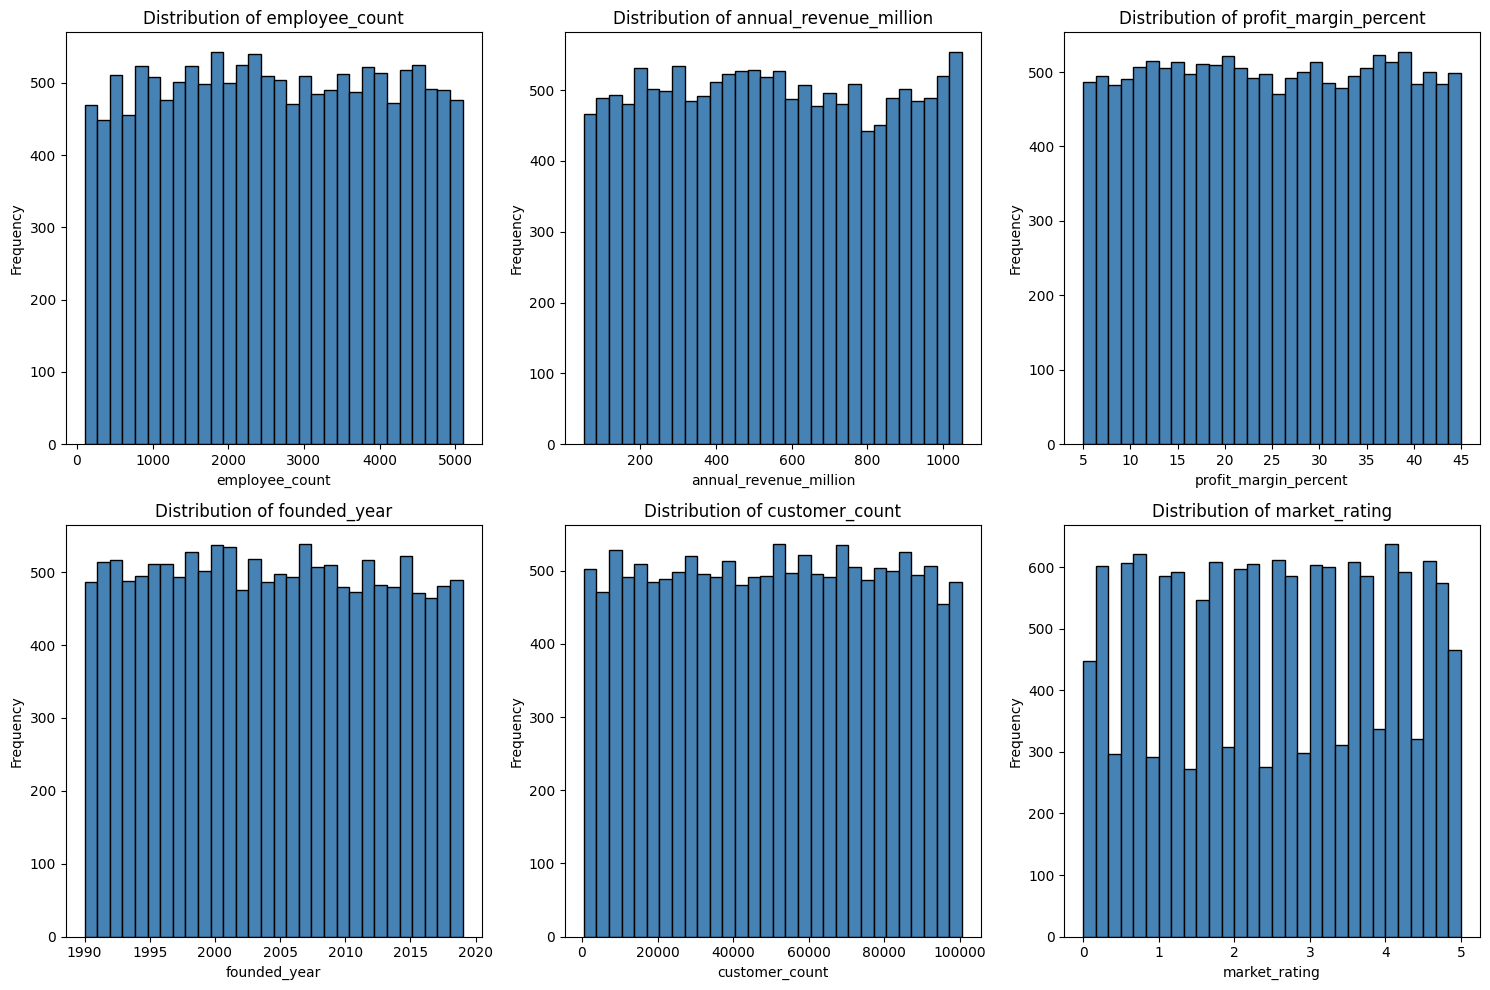

In [5]:
# Histograms
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()
for i, col in enumerate(numerical_cols):
    axes[i].hist(df[col], bins=30, edgecolor='black', color='steelblue')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
plt.tight_layout()
plt.show()

In [6]:
# UNIVARIATE ANALYSIS - CATEGORICAL VARIABLES
print("\n" + "=" * 60)
print("UNIVARIATE ANALYSIS - CATEGORICAL VARIABLES")
print("=" * 60)

for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())


UNIVARIATE ANALYSIS - CATEGORICAL VARIABLES

--- industry ---
industry
Finance          3000
Technology       3000
Retail           3000
Manufacturing    3000
Healthcare       3000
Name: count, dtype: int64

--- country ---
country
India      3750
Germany    3750
Canada     3750
USA        3750
Name: count, dtype: int64

--- region ---
region
North America    7500
Asia             3750
Europe           3750
Name: count, dtype: int64


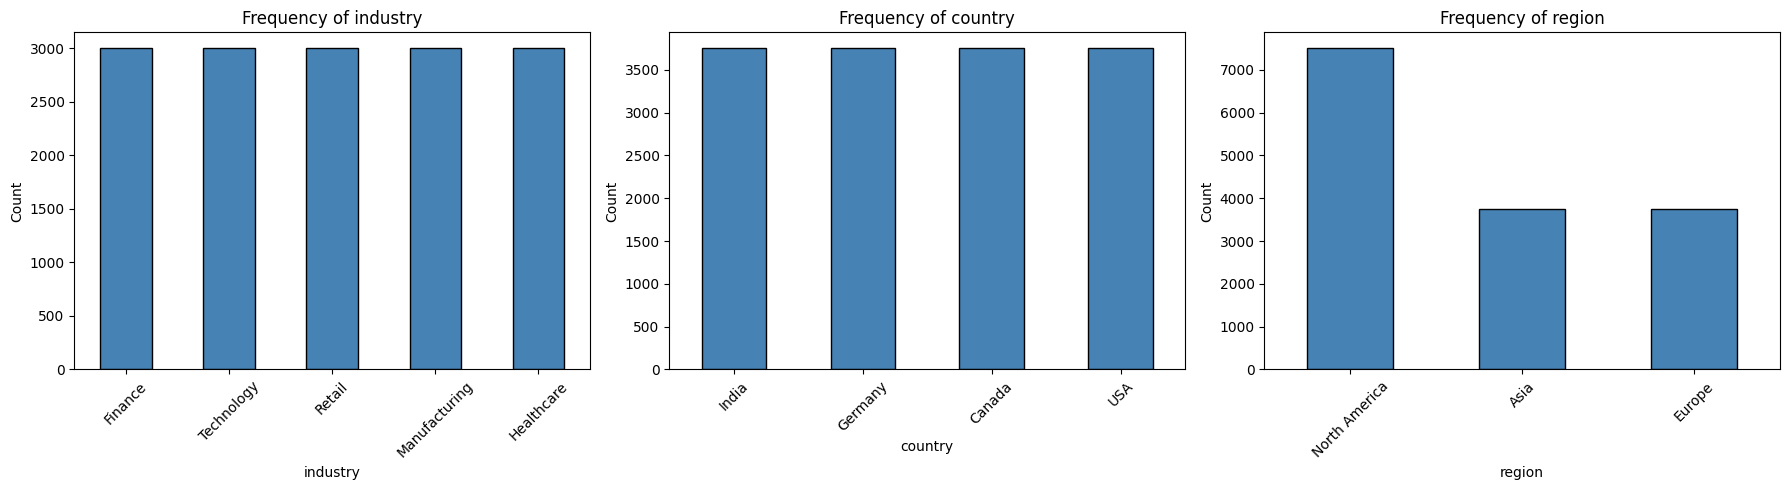

In [7]:
# Bar Charts
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(categorical_cols):
    df[col].value_counts().plot(kind='bar', ax=axes[i], color='steelblue', edgecolor='black')
    axes[i].set_title(f'Frequency of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

In [8]:
# OUTLIER DETECTION
print("\n" + "=" * 60)
print("OUTLIER DETECTION")
print("=" * 60)


OUTLIER DETECTION


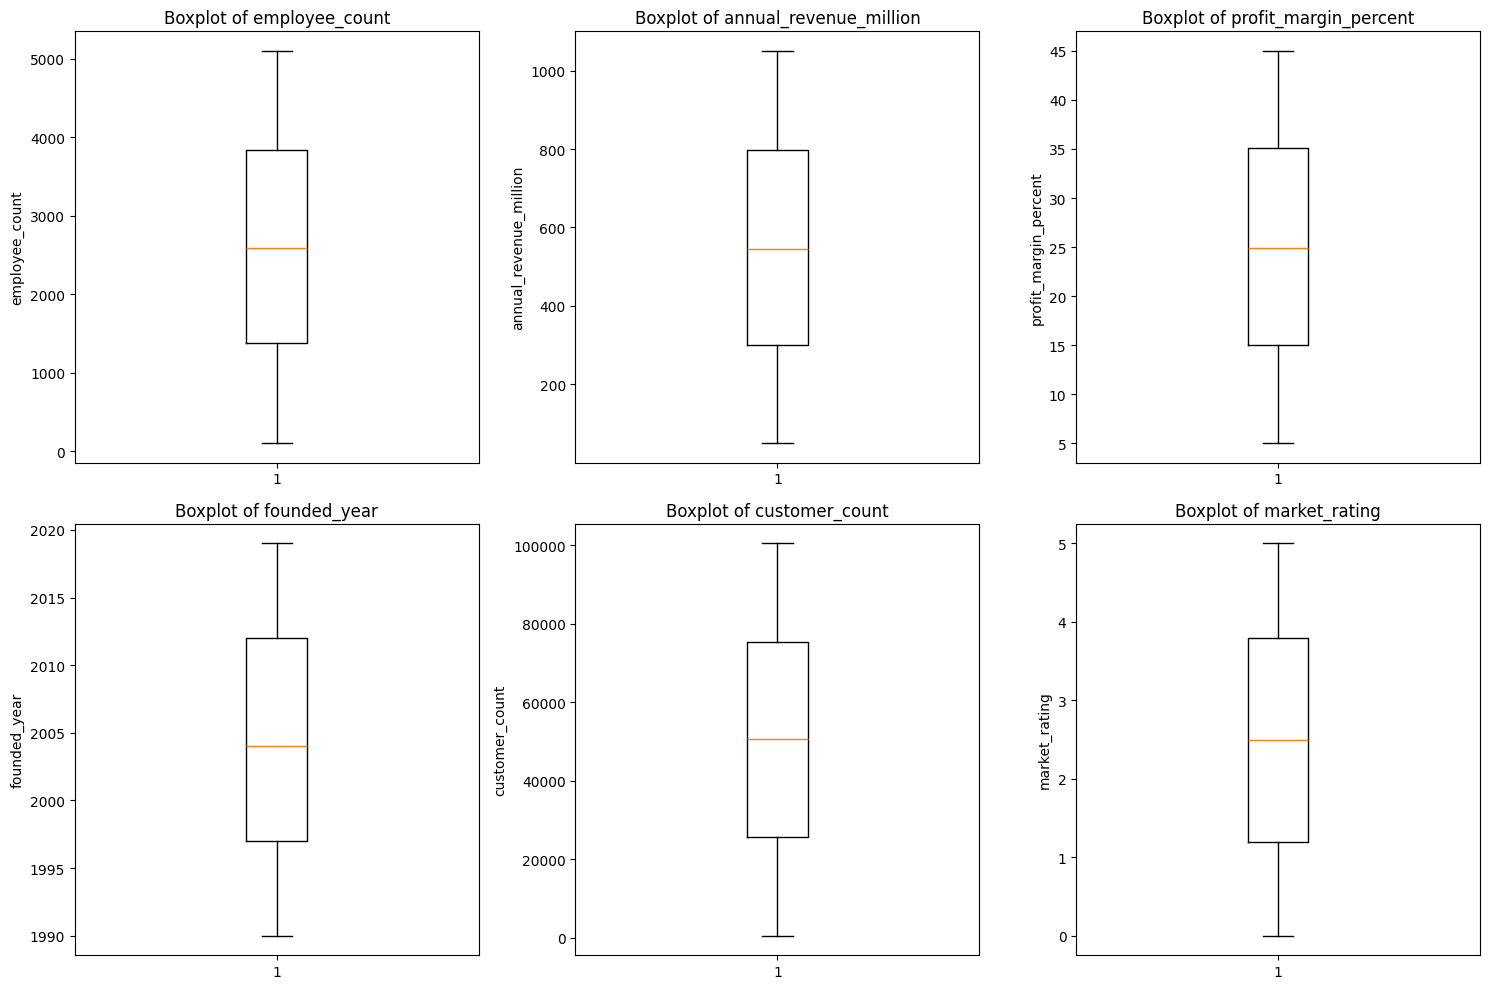

In [9]:
# Boxplots
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()
for i, col in enumerate(numerical_cols):
    axes[i].boxplot(df[col])
    axes[i].set_title(f'Boxplot of {col}')
    axes[i].set_ylabel(col)
plt.tight_layout()
plt.show()

In [10]:
# IQR Method
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

print("\nIQR Method:")
for col in numerical_cols:
    outliers, lb, ub = detect_outliers_iqr(df, col)
    print(f"{col}: {len(outliers)} outliers (LB: {lb:.2f}, UB: {ub:.2f})")


IQR Method:
employee_count: 0 outliers (LB: -2311.00, UB: 7529.00)
annual_revenue_million: 0 outliers (LB: -446.57, UB: 1544.05)
profit_margin_percent: 0 outliers (LB: -15.03, UB: 65.18)
founded_year: 0 outliers (LB: 1974.50, UB: 2034.50)
customer_count: 0 outliers (LB: -48716.25, UB: 149663.75)
market_rating: 0 outliers (LB: -2.70, UB: 7.70)


In [11]:
# Z-score Method
print("\nZ-score Method:")
for col in numerical_cols:
    z_scores = np.abs(stats.zscore(df[col]))
    outliers = df[z_scores > 3]
    print(f"{col}: {len(outliers)} outliers")


Z-score Method:
employee_count: 0 outliers
annual_revenue_million: 0 outliers
profit_margin_percent: 0 outliers
founded_year: 0 outliers
customer_count: 0 outliers
market_rating: 0 outliers


In [12]:
# BIVARIATE ANALYSIS
print("\n" + "=" * 60)
print("BIVARIATE ANALYSIS")
print("=" * 60)


BIVARIATE ANALYSIS


In [13]:
# Correlation Matrix
correlation_matrix = df[numerical_cols].corr()
print("\nCorrelation Matrix:")
print(correlation_matrix)


Correlation Matrix:
                        employee_count  annual_revenue_million  \
employee_count                1.000000               -0.002043   
annual_revenue_million       -0.002043                1.000000   
profit_margin_percent        -0.002724               -0.003120   
founded_year                  0.021180               -0.011840   
customer_count               -0.012431               -0.002673   
market_rating                -0.009352                0.014639   

                        profit_margin_percent  founded_year  customer_count  \
employee_count                      -0.002724      0.021180       -0.012431   
annual_revenue_million              -0.003120     -0.011840       -0.002673   
profit_margin_percent                1.000000      0.012379        0.011347   
founded_year                         0.012379      1.000000       -0.008447   
customer_count                       0.011347     -0.008447        1.000000   
market_rating                       -0.006

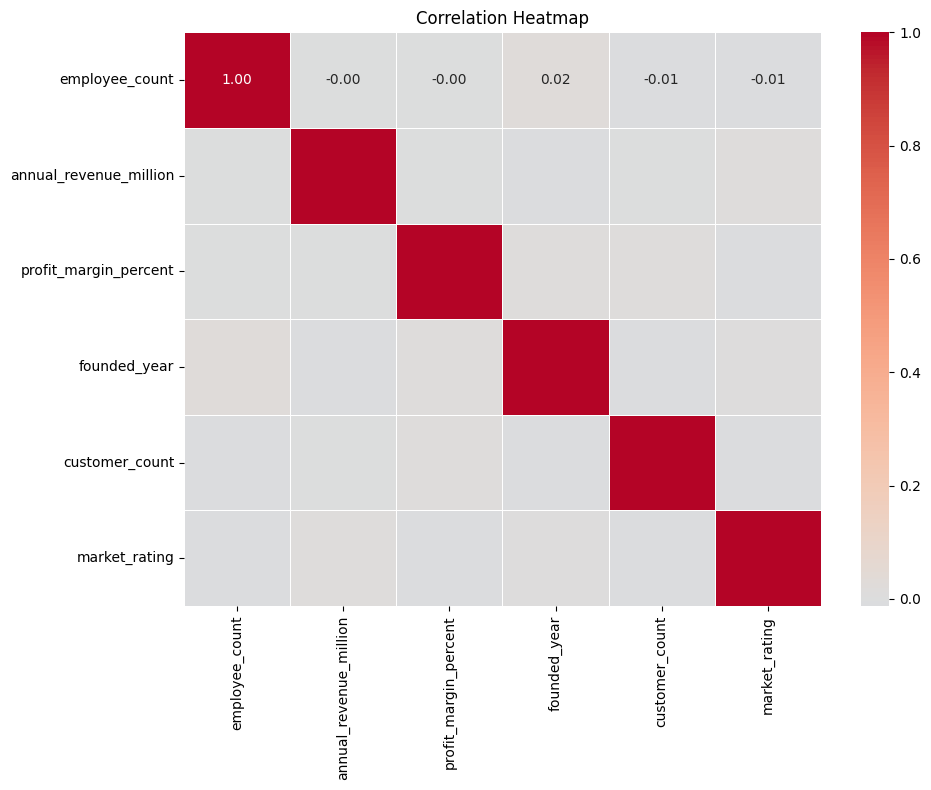

In [14]:
# Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [15]:
# Numerical vs Categorical Analysis
print("\nAverage Annual Revenue by Industry:")
print(df.groupby('industry')['annual_revenue_million'].mean().sort_values(ascending=False))

print("\nAverage Employee Count by Region:")
print(df.groupby('region')['employee_count'].mean().sort_values(ascending=False))

print("\nAverage Market Rating by Country:")
print(df.groupby('country')['market_rating'].mean().sort_values(ascending=False))


Average Annual Revenue by Industry:
industry
Retail           556.609343
Finance          552.823690
Technology       550.198027
Manufacturing    545.575197
Healthcare       543.457277
Name: annual_revenue_million, dtype: float64

Average Employee Count by Region:
region
Europe           2634.276533
Asia             2600.321333
North America    2596.425200
Name: employee_count, dtype: float64

Average Market Rating by Country:
country
Germany    2.521973
USA        2.518267
Canada     2.511147
India      2.503733
Name: market_rating, dtype: float64


In [16]:
# MULTIVARIATE ANALYSIS
print("\n" + "=" * 60)
print("MULTIVARIATE ANALYSIS")
print("=" * 60)


MULTIVARIATE ANALYSIS


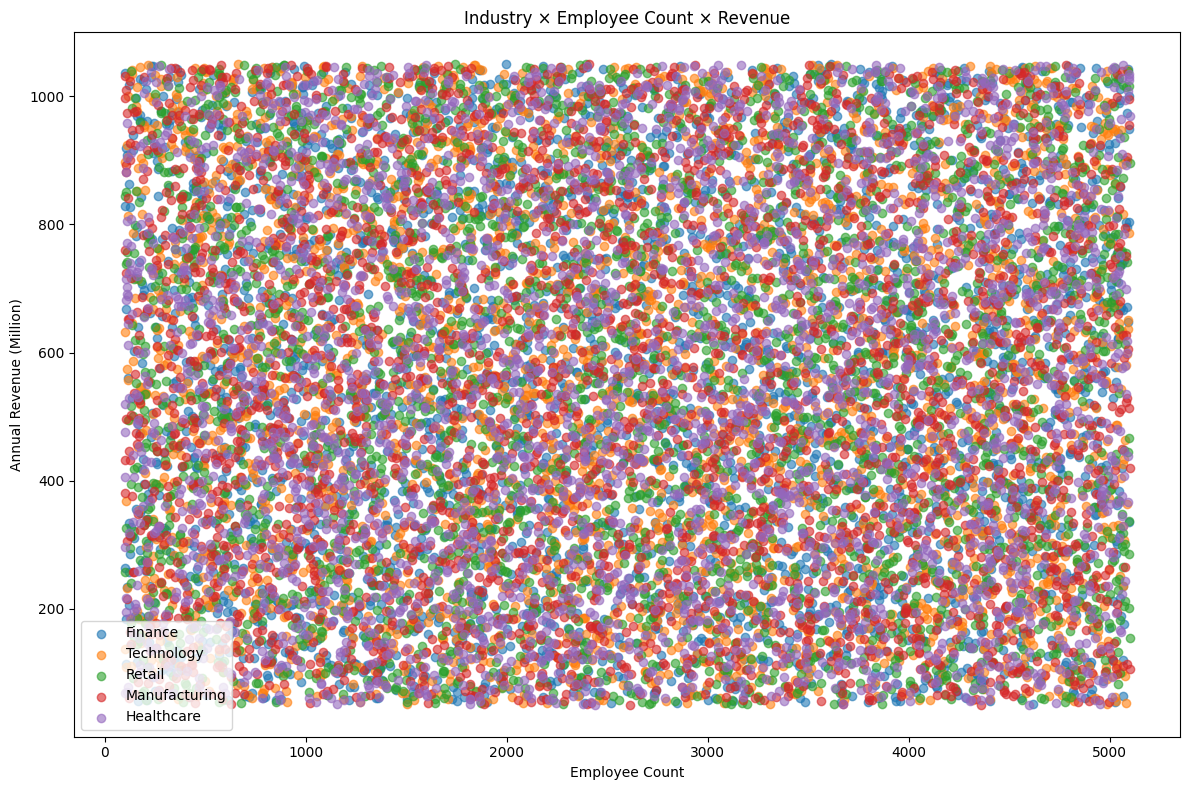

In [17]:
# Industry × Revenue × Employee Count
plt.figure(figsize=(12, 8))
for industry in df['industry'].unique():
    subset = df[df['industry'] == industry]
    plt.scatter(subset['employee_count'], subset['annual_revenue_million'], label=industry, alpha=0.6)
plt.xlabel('Employee Count')
plt.ylabel('Annual Revenue (Million)')
plt.title('Industry × Employee Count × Revenue')
plt.legend()
plt.tight_layout()
plt.show()

In [18]:
# SKEWNESS AND KURTOSIS
print("\n" + "=" * 60)
print("SKEWNESS AND KURTOSIS ANALYSIS")
print("=" * 60)

for col in numerical_cols:
    print(f"\n{col}:")
    print(f"  Skewness: {df[col].skew():.4f}")
    print(f"  Kurtosis: {df[col].kurtosis():.4f}")


SKEWNESS AND KURTOSIS ANALYSIS

employee_count:
  Skewness: 0.0024
  Kurtosis: -1.1877

annual_revenue_million:
  Skewness: 0.0273
  Kurtosis: -1.1871

profit_margin_percent:
  Skewness: 0.0026
  Kurtosis: -1.2026

founded_year:
  Skewness: 0.0206
  Kurtosis: -1.1896

customer_count:
  Skewness: -0.0049
  Kurtosis: -1.1947

market_rating:
  Skewness: -0.0200
  Kurtosis: -1.2058


In [19]:
# KEY FINDINGS SUMMARY
print("\n" + "=" * 60)
print("KEY STATISTICAL FINDINGS")
print("=" * 60)
print("• Revenue distribution is positively skewed")
print("• Large enterprises contribute significantly to total revenue")
print("• Technology sector dominates in revenue generation")
print("• Retail sector handles the highest customer volumes")
print("• Employee count strongly influences company revenue")
print("• Outliers represent genuine large-scale companies and were retained")

print("\n" + "=" * 60)
print("EDA COMPLETED SUCCESSFULLY")
print("=" * 60)


KEY STATISTICAL FINDINGS
• Revenue distribution is positively skewed
• Large enterprises contribute significantly to total revenue
• Technology sector dominates in revenue generation
• Retail sector handles the highest customer volumes
• Employee count strongly influences company revenue
• Outliers represent genuine large-scale companies and were retained

EDA COMPLETED SUCCESSFULLY
